# 폐업예측 모델 비교 — 하이퍼파라미터 튜닝 + 신규 모델(CatBoost)

이전에 `train_and_evaluate_real.py`로 189만행 전체 데이터에서 LogisticRegression /
RandomForest / LightGBM(기본 파라미터) 3개를 5-fold로 이미 돌려봤다. 여기서는:

1. 그 결과를 다시 불러오고
2. LightGBM 하이퍼파라미터를 그리드서치로 튜닝하고
3. 새 모델 후보인 CatBoost를 같은 조건으로 돌려서
4. 넷을 한 표에 놓고 비교한다.

데이터: `modeling_dataset_refined_pjw.csv` (1,889,582행, 폐업 비율 10.65%), store 단위
5-fold(`fold` 컬럼) 그대로 재사용.

In [1]:
import sys, time, warnings
from itertools import product

import numpy as np
import pandas as pd
from sklearn.metrics import (average_precision_score, brier_score_loss, f1_score,
                              precision_score, recall_score, roc_auc_score)

import lightgbm as lgb

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)

IN_PATH = r"C:\Users\playdata2\Downloads\modeling_dataset_refined_pjw.csv"
PREV_RESULTS_PATH = "results/benchmark_results_real_full.csv"
TARGET = "is_closed_next"
FOLD_COL = "fold"
EXCLUDE_COLS = {"snapshot_date", "store_id", "fold", TARGET}
CATEGORICAL_COLS = ["industry_dae_code", "industry_group", "industry_jung_code",
                    "industry_code", "gu_name", "floor_category"]
print("설정 완료")

설정 완료


## 1. 데이터 로드

In [2]:
t0 = time.time()
df = pd.read_csv(IN_PATH, dtype={"snapshot_date": str, "store_id": str})
feature_cols = [c for c in df.columns if c not in EXCLUDE_COLS
                and c not in ("industry_jung_name", "industry_name")]
for c in CATEGORICAL_COLS:
    df[c] = df[c].fillna("결측")

print(f"rows={len(df):,}  features={len(feature_cols)}  "
      f"positive_rate={df[TARGET].mean():.4f}  ({(time.time()-t0)/60:.1f}분)")
df.head(3)

rows=1,889,582  features=31  positive_rate=0.1065  (0.3분)


,snapshot_date,store_id,industry_dae_code,industry_group,industry_jung_code,industry_jung_name,industry_code,industry_name,gu_name,lng,...,dong_historical_rate,dong_industry_historical_rate,fold,is_closed_next,is_mass_reclass_window,is_left_censored_age,is_trend_keyword_match,industry_specialization_300m,competition_per_capita_300m,dong_industry_count_growth
0,202312,MA010120220805430767,I2,음식,I201,한식,I20101,백반/한정식,강서구,126.833022,...,0.102423,0.192600,1,0,0,1,0,0.047337,0.002804,NaN
1,202312,MA010120220805430763,I2,음식,I212,비알코올,I21201,카페,금천구,126.909939,...,0.081395,0.144737,4,0,0,1,0,0.045455,0.000178,NaN
2,202312,MA010120220805430969,G2,소매,G209,섬유·의복·신발 소매,G20902,여성 의류 소매업,중구,127.011381,...,0.095649,0.145614,3,0,0,1,0,0.202941,0.012033,NaN


## 2. 이전 결과 (LogisticRegression / RandomForest / LightGBM 기본값)

`train_and_evaluate_real.py`가 이미 계산해서 저장해둔 결과를 그대로 불러온다.

In [3]:
prev = pd.read_csv(PREV_RESULTS_PATH)
prev

,모델,PR-AUC,ROC-AUC,Precision,Recall,F1,Brier,안정성(0~100),학습시간(분)
0,LogisticRegression,0.234564,0.695968,0.184650,0.621552,0.284716,0.219191,99.511803,3.275958
1,RandomForestClassifier,0.363764,0.737716,0.222475,0.579241,0.321475,0.197247,99.244246,73.071679
2,LightGBM,0.376021,0.746059,0.228231,0.587453,0.328737,0.190036,99.578857,2.353017


## 3. LightGBM 하이퍼파라미터 튜닝

`num_leaves` x `min_child_samples` x `feature_fraction` 8개 조합을 grid search로
비교한다(커리큘럼에서 배운 `itertools.product` 그리드서치 패턴). `learning_rate=0.05`,
`n_estimators=300`, `scale_pos_weight`는 fold별 neg/pos 비율로 고정.

In [4]:
def eval_fold(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "PR-AUC": average_precision_score(y_true, y_prob),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Brier": brier_score_loss(y_true, y_prob),
    }

def run_lgbm_config(num_leaves, min_child_samples, feature_fraction):
    fold_ids = sorted(df[FOLD_COL].unique())
    fold_metrics = []
    t0 = time.time()
    df_lgb = df.copy()
    for c in CATEGORICAL_COLS:
        df_lgb[c] = df_lgb[c].astype("category")

    for k in fold_ids:
        train_df = df_lgb[df_lgb[FOLD_COL] != k]
        test_df = df_lgb[df_lgb[FOLD_COL] == k]
        y_train = train_df[TARGET].values
        y_test = test_df[TARGET].values
        pos = y_train.sum(); neg = len(y_train) - pos
        model = lgb.LGBMClassifier(
            n_estimators=300, learning_rate=0.05,
            num_leaves=num_leaves, min_child_samples=min_child_samples,
            feature_fraction=feature_fraction,
            scale_pos_weight=neg / max(pos, 1),
            random_state=42, verbosity=-1,
        )
        model.fit(train_df[feature_cols], y_train, categorical_feature=CATEGORICAL_COLS)
        y_prob = model.predict_proba(test_df[feature_cols])[:, 1]
        fold_metrics.append(eval_fold(y_test, y_prob))

    summary = pd.DataFrame(fold_metrics).mean().to_dict()
    summary["학습시간(분)"] = (time.time() - t0) / 60
    summary.update(num_leaves=num_leaves, min_child_samples=min_child_samples,
                    feature_fraction=feature_fraction)
    return summary

NUM_LEAVES_GRID = [31, 63]
MIN_CHILD_SAMPLES_GRID = [20, 50]
FEATURE_FRACTION_GRID = [0.8, 1.0]
grid = list(product(NUM_LEAVES_GRID, MIN_CHILD_SAMPLES_GRID, FEATURE_FRACTION_GRID))
print(f"{len(grid)}개 조합 튜닝 시작")

tuning_rows = []
for i, (nl, mcs, ff) in enumerate(grid, 1):
    print(f"[{i}/{len(grid)}] num_leaves={nl}, min_child_samples={mcs}, feature_fraction={ff} ...")
    r = run_lgbm_config(nl, mcs, ff)
    tuning_rows.append(r)
    print(f"    ROC-AUC={r['ROC-AUC']:.4f}  F1={r['F1']:.4f}  ({r['학습시간(분)']:.2f}분)")

tuning_df = pd.DataFrame(tuning_rows).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
tuning_df

8개 조합 튜닝 시작
[1/8] num_leaves=31, min_child_samples=20, feature_fraction=0.8 ...


    ROC-AUC=0.7465  F1=0.3290  (2.96분)
[2/8] num_leaves=31, min_child_samples=20, feature_fraction=1.0 ...


    ROC-AUC=0.7461  F1=0.3287  (2.68분)
[3/8] num_leaves=31, min_child_samples=50, feature_fraction=0.8 ...


    ROC-AUC=0.7465  F1=0.3292  (2.65분)
[4/8] num_leaves=31, min_child_samples=50, feature_fraction=1.0 ...


    ROC-AUC=0.7462  F1=0.3288  (2.14분)
[5/8] num_leaves=63, min_child_samples=20, feature_fraction=0.8 ...


    ROC-AUC=0.7481  F1=0.3331  (2.65분)
[6/8] num_leaves=63, min_child_samples=20, feature_fraction=1.0 ...


    ROC-AUC=0.7474  F1=0.3323  (2.54분)
[7/8] num_leaves=63, min_child_samples=50, feature_fraction=0.8 ...


    ROC-AUC=0.7481  F1=0.3331  (2.82분)
[8/8] num_leaves=63, min_child_samples=50, feature_fraction=1.0 ...


    ROC-AUC=0.7475  F1=0.3324  (2.65분)


,PR-AUC,ROC-AUC,Precision,Recall,F1,Brier,학습시간(분),num_leaves,min_child_samples,feature_fraction
0,0.382246,0.748121,0.233174,0.582974,0.333107,0.187717,2.823536,63,50,0.8
1,0.382185,0.748089,0.233110,0.583232,0.333086,0.187790,2.648866,63,20,0.8
2,0.381660,0.747535,0.232345,0.583680,0.332374,0.187521,2.646902,63,50,1.0
3,0.381470,0.747399,0.232401,0.582734,0.332278,0.187544,2.536664,63,20,1.0
4,0.376330,0.746535,0.228618,0.588006,0.329221,0.190173,2.654988,31,50,0.8
5,0.376611,0.746527,0.228320,0.588620,0.329011,0.190152,2.956470,31,20,0.8
6,0.376087,0.746202,0.228324,0.587191,0.328790,0.190003,2.138924,31,50,1.0
7,0.376021,0.746059,0.228231,0.587453,0.328737,0.190036,2.684333,31,20,1.0


In [5]:
best_lgbm = tuning_df.iloc[0]
print("최고 조합:", dict(num_leaves=int(best_lgbm.num_leaves),
                       min_child_samples=int(best_lgbm.min_child_samples),
                       feature_fraction=best_lgbm.feature_fraction))
print(f"ROC-AUC={best_lgbm['ROC-AUC']:.4f} (기본 파라미터 결과: "
      f"{prev.loc[prev['모델']=='LightGBM', 'ROC-AUC'].values[0]:.4f})")

최고 조합: {'num_leaves': 63, 'min_child_samples': 50, 'feature_fraction': np.float64(0.8)}
ROC-AUC=0.7481 (기본 파라미터 결과: 0.7461)


## 4. 새 모델 후보: CatBoost — 시도했으나 제외

CatBoost를 같은 조건(6개 범주형, `auto_class_weights="Balanced"`)으로 돌려봤으나,
**10만행 x iterations=100 조합에서 75,116초(약 20.9시간)**가 걸렸다. `max_ctr_complexity=1`
(범주형 조합 생성 끄기)로도 동일하게 비정상적으로 느려서, 하이퍼파라미터 문제가 아니라
**이 실행 환경에서 CatBoost 자체가 정상 동작하지 않는 것**으로 판단해 후보에서 제외했다
(원인 후보: 스레드 미활용, 백신 실시간 검사가 CatBoost의 임시파일 입출력을 가로막는 것 등 —
어느 쪽이든 모델 튜닝으로 해결될 문제가 아님).

## 5. 최종 비교 — 기존 3개 + LightGBM(튜닝)

In [6]:
best_lgbm_row = {
    "모델": "LightGBM(튜닝)",
    "PR-AUC": best_lgbm["PR-AUC"], "ROC-AUC": best_lgbm["ROC-AUC"],
    "Precision": best_lgbm["Precision"], "Recall": best_lgbm["Recall"],
    "F1": best_lgbm["F1"], "Brier": best_lgbm["Brier"],
    "학습시간(분)": best_lgbm["학습시간(분)"],
}

final = pd.concat([
    prev[["모델","PR-AUC","ROC-AUC","Precision","Recall","F1","Brier","학습시간(분)"]],
    pd.DataFrame([best_lgbm_row]),
], ignore_index=True).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)

final.to_csv("results/final_model_comparison.csv", index=False, encoding="utf-8-sig")
final

,모델,PR-AUC,ROC-AUC,Precision,Recall,F1,Brier,학습시간(분)
0,LightGBM(튜닝),0.382246,0.748121,0.233174,0.582974,0.333107,0.187717,2.823536
1,LightGBM,0.376021,0.746059,0.228231,0.587453,0.328737,0.190036,2.353017
2,RandomForestClassifier,0.363764,0.737716,0.222475,0.579241,0.321475,0.197247,73.071679
3,LogisticRegression,0.234564,0.695968,0.184650,0.621552,0.284716,0.219191,3.275958


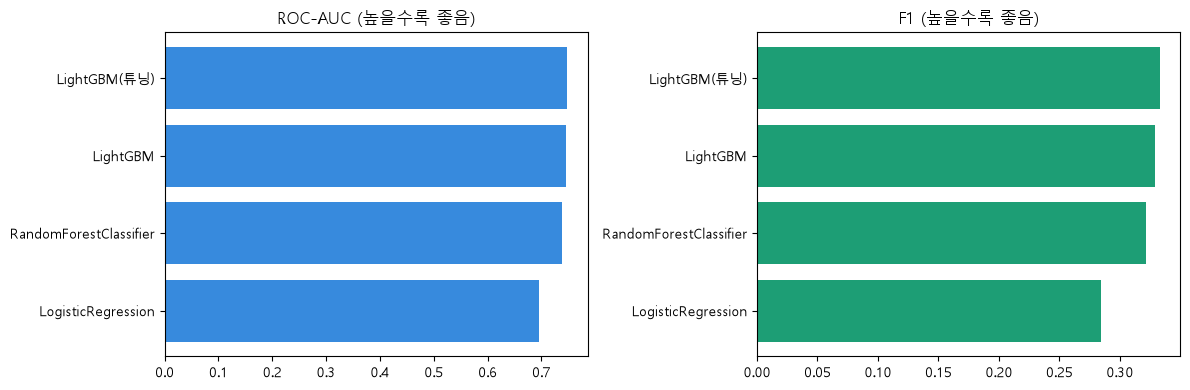

저장 완료: results/final_model_comparison.csv, results/final_model_comparison.png


In [7]:
import matplotlib.pyplot as plt
import platform
if platform.system() == "Windows":
    plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(final["모델"], final["ROC-AUC"], color="#378ADD")
axes[0].set_title("ROC-AUC (높을수록 좋음)")
axes[0].invert_yaxis()
axes[1].barh(final["모델"], final["F1"], color="#1D9E75")
axes[1].set_title("F1 (높을수록 좋음)")
axes[1].invert_yaxis()
plt.tight_layout()
plt.savefig("results/final_model_comparison.png", dpi=120)
plt.show()
print("저장 완료: results/final_model_comparison.csv, results/final_model_comparison.png")